# Fourier Transform of rect() and Shifted rect()

## Time shift property
$$
x(t-t_0) \Leftrightarrow   e^{-j 2\pi f t_0}X(f)
$$

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()


Basic Material version: 16.002-0.1


In [13]:
colors = bm.get_colors()
import numpy as np
import matplotlib.pyplot as plt

from sympy import lambdify, oo, Symbol, Piecewise
from sympy import fourier_transform
from sympy.abc import A,B,t,f 
from sympy import re, im 

import textwrap

In [14]:
tlim = 3
tt = np.linspace(-tlim, tlim, 1000)
flim = 3
ff = np.linspace(-flim, flim, 1000)
ts = Symbol('t')

## Define Two Functions of Interest

In [15]:
def basic_rect(A = -1/2,B = 1/2):
    return Piecewise((0, t <= A),(1, t < B),(0, True))

# rect
f1 = basic_rect()
lam_f1 = lambdify(ts, f1, modules=['numpy'])

# shifted rect
f2 = basic_rect(0,1)
lam_f2 = lambdify(ts, f2, modules=['numpy'])

So here we have 
$$ f_2(t) = f_1(t-0.5) $$
so we would expect
$$
{\cal F}\{f_2(t)\} = e^{-2\pi j f/2} {\cal F}\{f_1(t)\} = e^{-\pi j f} {\cal F}\{f_1(t)\}
$$

## Plot time ftns

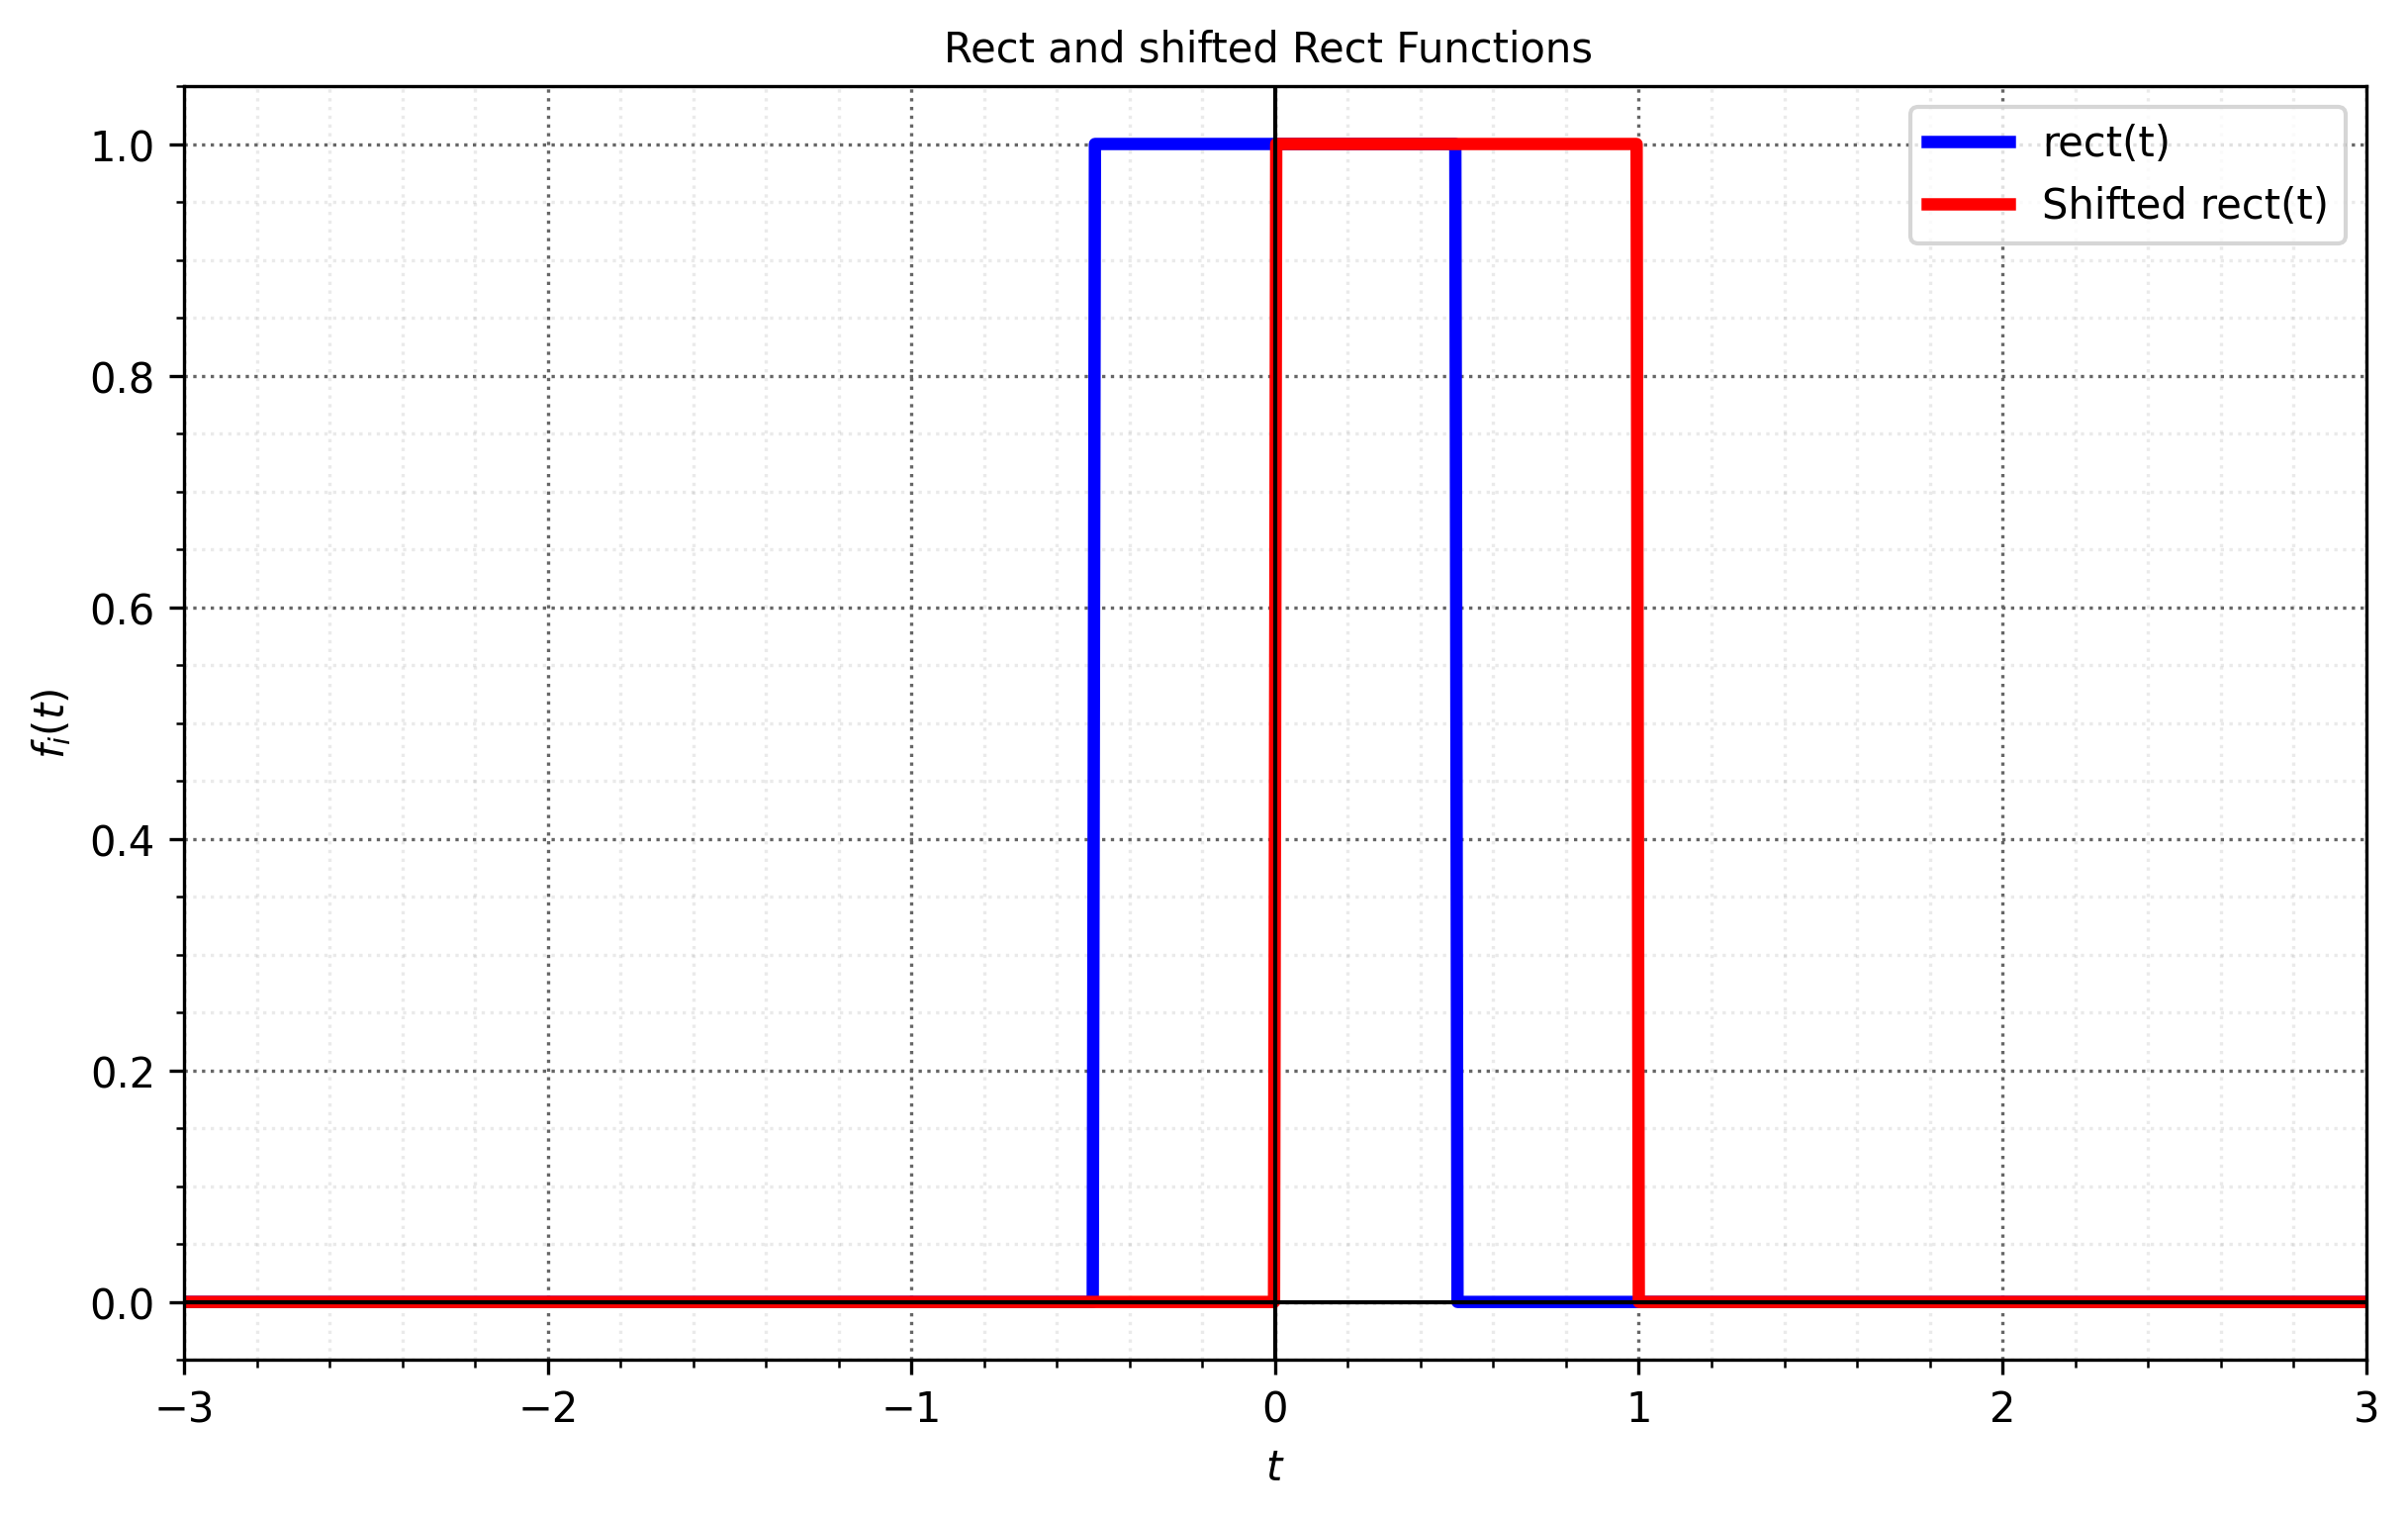

In [16]:
fig = plt.figure(figsize=(8, 5),dpi=300,constrained_layout = True)
plt.plot(tt, lam_f1(tt),'b',label='rect(t)',lw=3)
plt.plot(tt, lam_f2(tt),'r-',label='Shifted rect(t)',lw=3)

bm.nicegrid()
plt.legend()
plt.xlim(-tlim,tlim)
plt.xlabel('$t$')
plt.ylabel('$f_i(t)$')
plt.title('Rect and shifted Rect Functions ')
fig.savefig('./figs/T7_ex3_1.pdf', format='pdf', dpi=300)
plt.show()

## Transform and plot Real/Imag Parts

In [17]:
Q1 = fourier_transform(f1, t, f)
lam_Q1i = lambdify(f, im(Q1), modules=['numpy'])
lam_Q1r = lambdify(f, re(Q1), modules=['numpy'])

Q2 = fourier_transform(f2, t, f)
lam_Q2i = lambdify(f, im(Q2), modules=['numpy'])
lam_Q2r = lambdify(f, re(Q2), modules=['numpy'])

# expected phase shift
phases = -np.pi*ff

## Fourier Transform of original signal

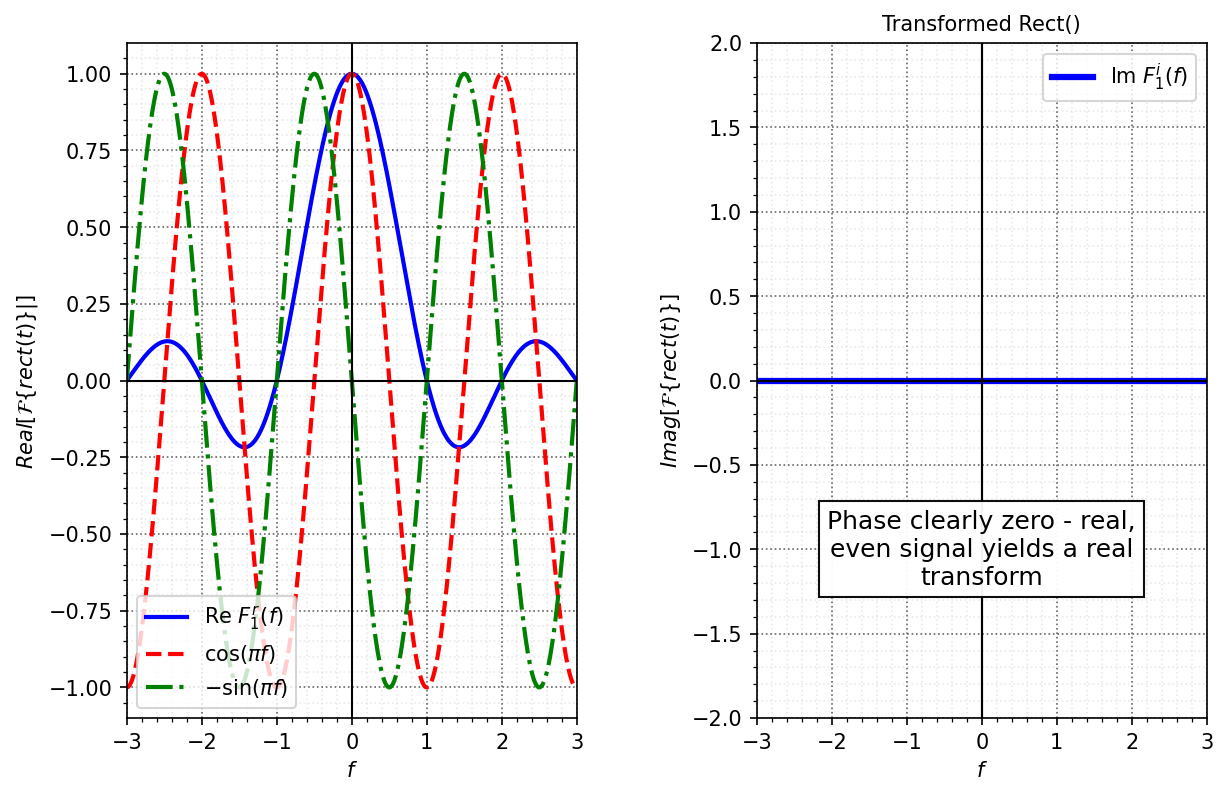

In [18]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,5), dpi=150)
fig.tight_layout(pad=5.0)
ax1.plot(ff, lam_Q1r(ff),'b',label='Re $F^r_1(f)$')
ax1.plot(ff, np.cos(phases),'r--',label=r'$\cos(\pi f)$')
ax1.plot(ff, np.sin(phases),'g-.',label=r'$-\sin(\pi f)$')
ax1.set_ylabel('$Real[{\cal F}\{ rect(t)\}|]$')
ax1.set_xlabel('$f$')
ax1.set_xlim(-flim,flim)
ax1.legend(loc=3)
bm.nicegrid(ax1)

ax2.plot(ff, lam_Q1i(ff),'b-',label='Im $F^i_1(f)$',lw=3)
ax2.set_title('Phase')
ax2.set_ylabel('$Imag[{\cal F}\{ rect(t)\}]$')
ax2.set_xlabel('$f$')
ax2.set_xlim(-flim,flim)
ax2.set_ylim(-2,2)
bm.nicegrid(ax2)
plt.legend()

plt.title('Transformed Rect()')
bm.nicegrid()
msg = 'Phase clearly zero - real, even signal yields a real transform'
ax2.text(0.5, .25, textwrap.fill(msg, 30), transform=ax2.transAxes, fontsize=12,
         verticalalignment='center', horizontalalignment='center',
         bbox=dict(facecolor='white', alpha=0.95))
fig.savefig('./figs/T7_ex3_2.pdf', format='pdf', dpi=600)
plt.subplots_adjust(left=0.05,
                    bottom=0.05, 
                    right=0.95, 
                    top=0.95, 
                    wspace=0.4, 
                    hspace=0.4)
plt.show()

## Shifted Signal - Real and Imaginary Part

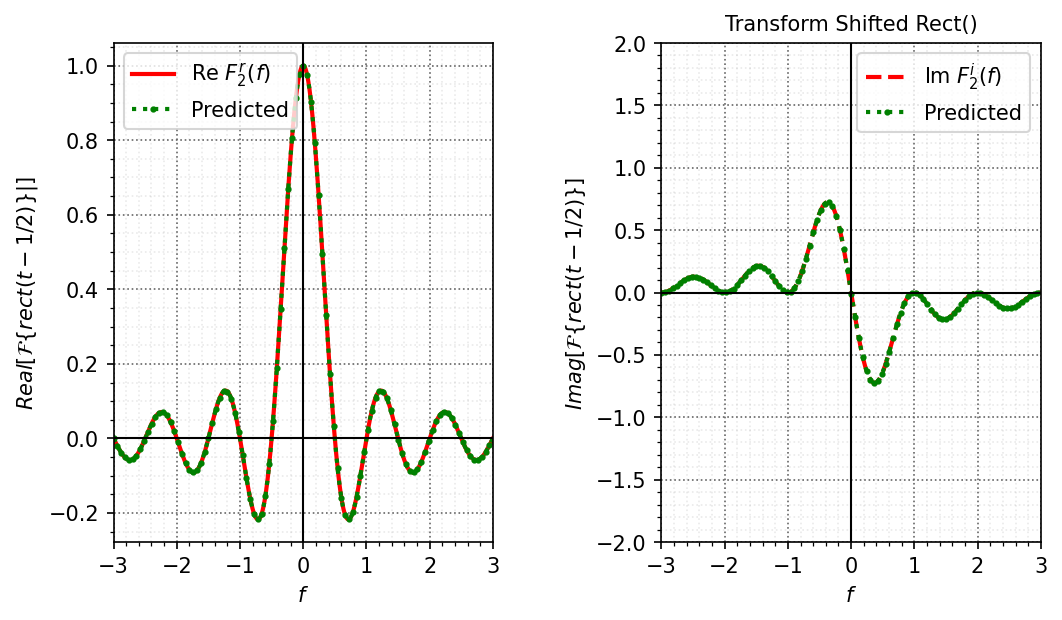

In [19]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,5), dpi=150)
fig.tight_layout(pad=5.0)
ax1.plot(ff, lam_Q2r(ff),'r',label='Re $F^r_2(f)$')
ax1.plot(ff, lam_Q1r(ff)*np.cos(phases) - lam_Q1i(ff)*np.sin(phases) ,'go:',label='Predicted',markevery=10,ms=2)
ax1.set_ylabel('$Real[{\cal F}\{ rect(t-1/2)\}|]$')
ax1.set_xlabel('$f$')
ax1.set_xlim(-flim,flim)
ax1.legend(loc=2)
bm.nicegrid(ax1)

ax2.plot(ff, lam_Q2i(ff),'r--',label='Im $F^i_2(f)$')
ax2.plot(ff, lam_Q1r(ff)*np.sin(phases) + lam_Q1i(ff)*np.cos(phases) ,'go:',label='Predicted',markevery=10,ms=2)
ax2.set_ylabel('$Imag[{\cal F}\{ rect(t-1/2)\}]$')
ax2.set_xlabel('$f$')
ax2.set_xlim(-flim,flim)
ax2.set_ylim(-2,2)
bm.nicegrid(ax2)
plt.legend()
plt.title('Transform Shifted Rect()')
fig.savefig('./figs/T7_ex3_3.pdf', format='pdf', dpi=300)
plt.show()


## Original Signal - Magnitude and Phase

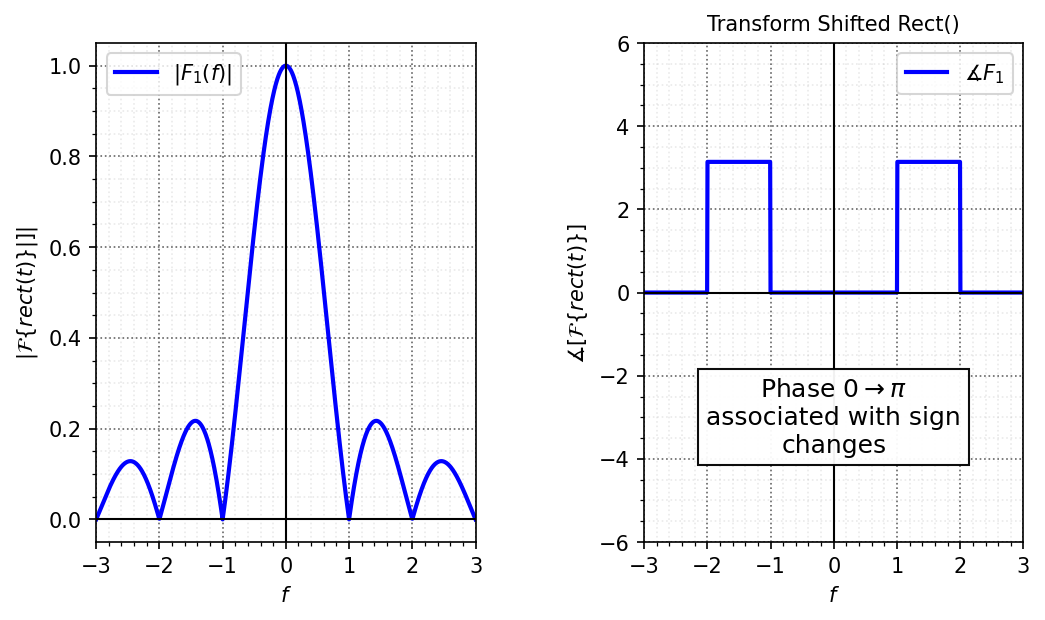

In [29]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,5), dpi=150)
fig.tight_layout(pad=5.0)
ax1.plot(ff, np.abs(lam_Q1r(ff)+1j*lam_Q1i(ff)),'b',label='$|F_1(f)|$')
ax1.set_ylabel('$|{\cal F}\{ rect(t)\}|]|$')
ax1.set_xlabel('$f$')
ax1.set_xlim(-flim,flim)
ax1.legend(loc=2)
bm.nicegrid(ax1)

ax2.plot(ff, np.unwrap(np.angle(lam_Q1r(ff)+1j*lam_Q1i(ff))),'b-',label='$\measuredangle F_1$')
ax2.set_ylabel('$\measuredangle[{\cal F}\{rect(t)\}]$')
ax2.set_xlabel('$f$')
ax2.set_xlim(-flim,flim)
ax2.set_ylim(-6,6)
bm.nicegrid(ax2)
msg = r"Phase $0 \to \pi$ associated with sign changes"
ax2.text(0.5, .25, textwrap.fill(msg, 20), transform=ax2.transAxes, fontsize=12,
         verticalalignment='center', horizontalalignment='center',
         bbox=dict(facecolor='white', alpha=0.95))

plt.legend()
plt.title('Transform Shifted Rect()')
fig.savefig('./figs/T7_ex3_4a.pdf', format='pdf', dpi=300)
plt.show()

## Shifted Signal - Magnitude and Phase

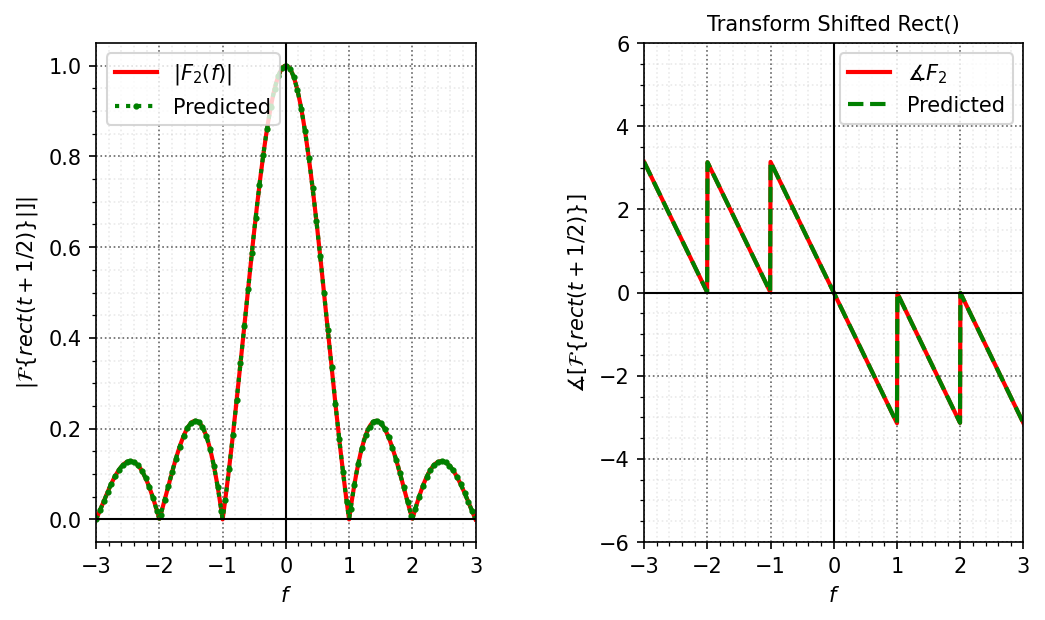

In [11]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,5), dpi=150)
fig.tight_layout(pad=5.0)
ax1.plot(ff, np.abs(lam_Q2r(ff)+1j*lam_Q2i(ff)),'r',label='$|F_2(f)|$')
ax1.plot(ff, np.abs(lam_Q1r(ff)+1j*lam_Q1i(ff)),'go:',label='Predicted',markevery=10,ms=2)
ax1.set_ylabel('$|{\cal F}\{ rect(t+1/2)\}|]|$')
ax1.set_xlabel('$f$')
ax1.set_xlim(-flim,flim)
ax1.legend(loc=2)
bm.nicegrid(ax1)

ax2.plot(ff, np.unwrap(np.angle(lam_Q2r(ff)+1j*lam_Q2i(ff))),'r-',lw=2,label='$\measuredangle F_2$')
F2r_pred = np.cos(np.pi*ff)*lam_Q1r(ff)
F2i_pred = -np.sin(np.pi*ff)*lam_Q1r(ff)
phases = np.angle(F2r_pred + 1j*F2i_pred)
ax2.plot(ff, np.unwrap(phases), 'g--', label='Predicted')
ax2.set_ylabel('$\measuredangle[{\cal F}\{ rect(t+1/2)\}]$')
ax2.set_xlabel('$f$')
ax2.set_xlim(-flim,flim)
ax2.set_ylim(-6,6)
bm.nicegrid(ax2)
plt.legend()
plt.title('Transform Shifted Rect()')
fig.savefig('./figs/T7_ex3_4.pdf', format='pdf', dpi=300)
plt.show()